## Classifying Interactions Valence Levels

### Not Enough Behaviors to get Accurate Result

In [1]:
# --- Core Python ---
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path
Libraries loaded successfully


In [2]:
feature_matrix = pd.read_pickle(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\Raw-Breathmatrics-Features")
# feature_matrix = pd.read_pickle(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\Raw-Breathmatrics-Features-More")
feature_matrix.columns

Index(['Behavior', 'Start', 'Stop', 'Duration', 'PreBoutRespRate', 'Trial', 'Subject', 'Condition', 'Rank', 'Type', 'Label', 'n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_breathing_rate', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol', 'cv_tidal_vol', 'minute_ventilation', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'exhale_duty_cycle', 'resp_rate_delta', 'breathing_rate_z'], dtype='object')

In [3]:
feature_matrix["Condition"].value_counts()

Condition
RI1     208
BLRI     69
RI2      25
Name: count, dtype: int64

### Clarifying Features and Targets

In [4]:
# Keep only target classes of interest
TARGET_COL = "Condition"
TARGET_CLASSES = ["RI1", "RI2"]

df = feature_matrix.copy()
df = df[df[TARGET_COL].isin(TARGET_CLASSES)].reset_index(drop=True)

# Explicit metadata + non-feature columns to exclude
EXCLUDE_FROM_FEATURES = {
    TARGET_COL,
    "Behavior",
    "Start",
    "Stop",
    "Duration",
    "Trial",
    "Subject",
    "Rank",
    "Type",
    "Label",
}

# Add any pre-defined metadata columns if present
if "METADATA_COLS" in globals() and isinstance(METADATA_COLS, (list, tuple, set)):
    EXCLUDE_FROM_FEATURES.update(METADATA_COLS)

# Keep only numeric respiratory features
candidate_feature_cols = [
    c for c in df.columns
    if c not in EXCLUDE_FROM_FEATURES and pd.api.types.is_numeric_dtype(df[c])
]

X_all = df[candidate_feature_cols].copy()
y = df[TARGET_COL].copy()

# Optional grouping variable for group-aware CV to prevent leakage across recordings
# Prefer Trial (if recording-level), otherwise fallback to Subject, else None.
groups = None
if "Trial" in df.columns:
    groups = df["Trial"].copy()
elif "Subject" in df.columns:
    groups = df["Subject"].copy()

### Building Pipelines

In [5]:
# Build CV strategy: grouped splits when possible, otherwise stratified shuffled folds
if groups is not None and groups.nunique() >= 3:
    n_splits = min(5, groups.nunique())
    cv = GroupKFold(n_splits=n_splits)
    cv_mode = f"GroupKFold(n_splits={n_splits})"
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

# Drop feature columns with too many missing values
MAX_MISSING_FRAC = 0.40
missing_frac = X_all.isna().mean(axis=0)
kept_feature_cols = missing_frac[missing_frac <= MAX_MISSING_FRAC].index.tolist()
dropped_feature_cols = missing_frac[missing_frac > MAX_MISSING_FRAC].sort_values(ascending=False)

X = X_all[kept_feature_cols].copy()

# Preprocessing pipeline with imputation + scaling (for linear models and SVM)
preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Preprocessing pipeline with imputation only (for tree-based models)
preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

# End-to-end model pipelines (safe against leakage when used in CV)
logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced")),
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )),
])

print(f"Rows retained after target filter: {len(df)}")
print(f"Target class counts:\n{y.value_counts(dropna=False)}\n")
print(f"Candidate numeric resp features: {len(candidate_feature_cols)}")
print(f"Features kept (<= {MAX_MISSING_FRAC:.0%} missing): {X.shape[1]}")
print(f"Features dropped (> {MAX_MISSING_FRAC:.0%} missing): {len(dropped_feature_cols)}")
if len(dropped_feature_cols):
    print("Dropped columns and missing fraction:")
    display(dropped_feature_cols.to_frame(name="missing_fraction"))

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"groups available: {groups is not None}")
print(f"CV strategy: {cv_mode}")

Rows retained after target filter: 233
Target class counts:
Condition
RI1    208
RI2     25
Name: count, dtype: int64

Candidate numeric resp features: 27
Features kept (<= 40% missing): 25
Features dropped (> 40% missing): 2
Dropped columns and missing fraction:


,missing_fraction
cv_inhale_pause_dur,0.763948
cv_exhale_pause_dur,0.442060


X shape: (233, 25)
y shape: (233,)
groups available: True
CV strategy: GroupKFold(n_splits=5)


### Running Pipelines/Models

In [6]:
from sklearn.base import clone
from sklearn.metrics import f1_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# Prefer stratified + grouped folds to preserve class balance while preventing recording leakage.
if groups is not None and pd.Series(groups).nunique() >= 3:
    n_splits_eval = min(5, pd.Series(groups).nunique())
    cv_eval = StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_eval_mode = f"StratifiedGroupKFold(n_splits={n_splits_eval}, shuffle=True)"
else:
    n_splits_eval = 5
    cv_eval = StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_eval_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

# Class weights summary (useful sanity check for imbalance severity)
classes = np.sort(y.unique())
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
class_weight_map = dict(zip(classes, class_weights))
print(f"CV for evaluation: {cv_eval_mode}")
print("Computed balanced class weights:", class_weight_map)

def make_split_iterator():
    if groups is not None and pd.Series(groups).nunique() >= 3:
        return StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42).split(X, y, groups=groups)
    return StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42).split(X, y)

def evaluate_imbalanced_pipeline(base_model, model_name, split_iterator):
    bal_acc_scores, macro_f1_scores = [], []
    per_class_recall = []
    y_true_all, y_pred_all = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Fold-specific sample weights for additional minority support during fit.
        fold_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

        model = clone(base_model)
        model.fit(X_train, y_train, model__sample_weight=fold_sample_weights)

        y_pred = model.predict(X_test)

        # Some grouped folds can miss a rare class in y_test; score on classes present in this fold.
        present_classes = np.sort(y_test.unique())
        bal_acc = recall_score(
            y_test, y_pred, labels=present_classes, average="macro", zero_division=0
        )
        macro_f1 = f1_score(
            y_test, y_pred, labels=present_classes, average="macro", zero_division=0
        )

        fold_recalls = np.full(len(classes), np.nan)
        present_recalls = recall_score(
            y_test, y_pred, labels=present_classes, average=None, zero_division=0
        )
        for i, cls in enumerate(classes):
            if cls in present_classes:
                fold_recalls[i] = present_recalls[np.where(present_classes == cls)[0][0]]

        bal_acc_scores.append(bal_acc)
        macro_f1_scores.append(macro_f1)
        per_class_recall.append(fold_recalls)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(f"[{model_name}] Fold {fold_idx}: balanced_acc={bal_acc:.3f}, macro_f1={macro_f1:.3f}")

    per_class_recall = np.array(per_class_recall, dtype=float)

    print(f"\n[{model_name}] Mean balanced accuracy: {np.mean(bal_acc_scores):.3f} +/- {np.std(bal_acc_scores):.3f}")
    print(f"[{model_name}] Mean macro F1: {np.mean(macro_f1_scores):.3f} +/- {np.std(macro_f1_scores):.3f}")

    print(f"\n[{model_name}] Mean per-class recall across folds:")
    for i, cls in enumerate(classes):
        cls_mean = np.nanmean(per_class_recall[:, i])
        cls_std = np.nanstd(per_class_recall[:, i])
        print(f"  {cls}: {cls_mean:.3f} +/- {cls_std:.3f}")

    print(f"\n[{model_name}] Classification report (pooled out-of-fold predictions):")
    print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
    cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in classes], columns=[f"pred_{c}" for c in classes])
    display(cm_df)

evaluate_imbalanced_pipeline(logreg_clf, "LogisticRegression", make_split_iterator())
print("\n" + "=" * 80 + "\n")
evaluate_imbalanced_pipeline(svm_clf, "SVM", make_split_iterator())
print("\n" + "=" * 80 + "\n")
evaluate_imbalanced_pipeline(rf_clf, "RandomForest", make_split_iterator())

CV for evaluation: StratifiedGroupKFold(n_splits=5, shuffle=True)
Computed balanced class weights: {'RI1': np.float64(0.5600961538461539), 'RI2': np.float64(4.66)}
[LogisticRegression] Fold 1: balanced_acc=0.531, macro_f1=0.446
[LogisticRegression] Fold 2: balanced_acc=0.571, macro_f1=0.411


[LogisticRegression] Fold 3: balanced_acc=0.497, macro_f1=0.492
[LogisticRegression] Fold 4: balanced_acc=0.895, macro_f1=0.494
[LogisticRegression] Fold 5: balanced_acc=0.465, macro_f1=0.449

[LogisticRegression] Mean balanced accuracy: 0.592 +/- 0.156
[LogisticRegression] Mean macro F1: 0.458 +/- 0.031

[LogisticRegression] Mean per-class recall across folds:
  RI1: 0.584 +/- 0.244
  RI2: 0.600 +/- 0.343

[LogisticRegression] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

         RI1       0.91      0.71      0.80       208
         RI2       0.15      0.44      0.23        25

    accuracy                           0.68       233
   macro avg       0.53      0.58      0.51       233
weighted avg       0.83      0.68      0.74       233



,pred_RI1,pred_RI2
true_RI1,148,60
true_RI2,14,11




[SVM] Fold 1: balanced_acc=0.656, macro_f1=0.371
[SVM] Fold 2: balanced_acc=0.571, macro_f1=0.411
[SVM] Fold 3: balanced_acc=0.619, macro_f1=0.610
[SVM] Fold 4: balanced_acc=0.790, macro_f1=0.395
[SVM] Fold 5: balanced_acc=0.526, macro_f1=0.417

[SVM] Mean balanced accuracy: 0.632 +/- 0.090
[SVM] Mean macro F1: 0.441 +/- 0.086

[SVM] Mean per-class recall across folds:
  RI1: 0.465 +/- 0.261
  RI2: 0.800 +/- 0.267

[SVM] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

         RI1       0.94      0.58      0.71       208
         RI2       0.16      0.68      0.26        25

    accuracy                           0.59       233
   macro avg       0.55      0.63      0.49       233
weighted avg       0.85      0.59      0.67       233



,pred_RI1,pred_RI2
true_RI1,120,88
true_RI2,8,17




[RandomForest] Fold 1: balanced_acc=0.500, macro_f1=0.471
[RandomForest] Fold 2: balanced_acc=0.500, macro_f1=0.389
[RandomForest] Fold 3: balanced_acc=0.500, macro_f1=0.473
[RandomForest] Fold 4: balanced_acc=0.494, macro_f1=0.494
[RandomForest] Fold 5: balanced_acc=0.481, macro_f1=0.439

[RandomForest] Mean balanced accuracy: 0.495 +/- 0.007
[RandomForest] Mean macro F1: 0.453 +/- 0.037

[RandomForest] Mean per-class recall across folds:
  RI1: 0.990 +/- 0.015
  RI2: 0.000 +/- 0.000

[RandomForest] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

         RI1       0.89      0.99      0.94       208
         RI2       0.00      0.00      0.00        25

    accuracy                           0.88       233
   macro avg       0.45      0.49      0.47       233
weighted avg       0.80      0.88      0.84       233



,pred_RI1,pred_RI2
true_RI1,205,3
true_RI2,25,0


In [7]:
print("\n\n" + "=" * 80)
print("BINARY CLASSIFICATION: RI (RI1+RI2) vs BLRI")
print("=" * 80 + "\n")

# Create binary target: collapse RI1 and RI2 → RI, keep BLRI
y_binary = df[TARGET_COL].replace({
    "RI1": "RI",
    "RI2": "RI",
    "BLRI": "BLRI"
}).copy()

print(f"Binary target distribution:\n{y_binary.value_counts(dropna=False)}\n")

# Binary class weights
classes_binary = np.sort(y_binary.unique())
class_weights_binary = compute_class_weight(class_weight="balanced", classes=classes_binary, y=y_binary)
class_weight_map_binary = dict(zip(classes_binary, class_weights_binary))
print("Computed balanced class weights (binary):", class_weight_map_binary)

def make_split_iterator_binary():
    if groups is not None and pd.Series(groups).nunique() >= 3:
        return StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42).split(X, y_binary, groups=groups)
    return StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42).split(X, y_binary)

def evaluate_binary_pipeline(base_model, model_name, split_iterator):
    bal_acc_scores, macro_f1_scores = [], []
    per_class_recall = []
    y_true_all, y_pred_all = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_binary.iloc[train_idx], y_binary.iloc[test_idx]

        fold_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

        model = clone(base_model)
        model.fit(X_train, y_train, model__sample_weight=fold_sample_weights)

        y_pred = model.predict(X_test)

        present_classes = np.sort(y_test.unique())
        bal_acc = recall_score(
            y_test, y_pred, labels=present_classes, average="macro", zero_division=0
        )
        macro_f1 = f1_score(
            y_test, y_pred, labels=present_classes, average="macro", zero_division=0
        )

        fold_recalls = np.full(len(classes_binary), np.nan)
        present_recalls = recall_score(
            y_test, y_pred, labels=present_classes, average=None, zero_division=0
        )
        for i, cls in enumerate(classes_binary):
            if cls in present_classes:
                fold_recalls[i] = present_recalls[np.where(present_classes == cls)[0][0]]

        bal_acc_scores.append(bal_acc)
        macro_f1_scores.append(macro_f1)
        per_class_recall.append(fold_recalls)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(f"[{model_name}] Fold {fold_idx}: balanced_acc={bal_acc:.3f}, macro_f1={macro_f1:.3f}")

    per_class_recall = np.array(per_class_recall, dtype=float)

    print(f"\n[{model_name}] Mean balanced accuracy: {np.mean(bal_acc_scores):.3f} +/- {np.std(bal_acc_scores):.3f}")
    print(f"[{model_name}] Mean macro F1: {np.mean(macro_f1_scores):.3f} +/- {np.std(macro_f1_scores):.3f}")

    print(f"\n[{model_name}] Mean per-class recall across folds:")
    for i, cls in enumerate(classes_binary):
        cls_mean = np.nanmean(per_class_recall[:, i])
        cls_std = np.nanstd(per_class_recall[:, i])
        print(f"  {cls}: {cls_mean:.3f} +/- {cls_std:.3f}")

    print(f"\n[{model_name}] Classification report (pooled out-of-fold predictions):")
    print(classification_report(y_true_all, y_pred_all, labels=classes_binary, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred_all, labels=classes_binary)
    cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in classes_binary], columns=[f"pred_{c}" for c in classes_binary])
    display(cm_df)

# Evaluate all three models on binary task
evaluate_binary_pipeline(logreg_clf, "LogisticRegression", make_split_iterator_binary())
print("\n" + "=" * 80 + "\n")
evaluate_binary_pipeline(svm_clf, "SVM", make_split_iterator_binary())
print("\n" + "=" * 80 + "\n")
evaluate_binary_pipeline(rf_clf, "RandomForest", make_split_iterator_binary())



BINARY CLASSIFICATION: RI (RI1+RI2) vs BLRI

Binary target distribution:
Condition
RI    233
Name: count, dtype: int64

Computed balanced class weights (binary): {'RI': np.float64(1.0)}


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 'RI'

Top features used in pairplot: ['mean_exhale_dur_sec', 'breathing_rate_hz', 'minute_ventilation', 'n_breaths', 'pct_breaths_with_exhale_pause', 'cv_inhale_dur']


,anova_f_score
mean_exhale_dur_sec,13.067159
breathing_rate_hz,11.560828
minute_ventilation,8.005142
n_breaths,7.997783
pct_breaths_with_exhale_pause,7.438617
cv_inhale_dur,6.956588
mean_ibi_sec,6.917524
exhale_duty_cycle,6.788220
cv_breathing_rate,6.587794
cv_exhale_dur,6.171104


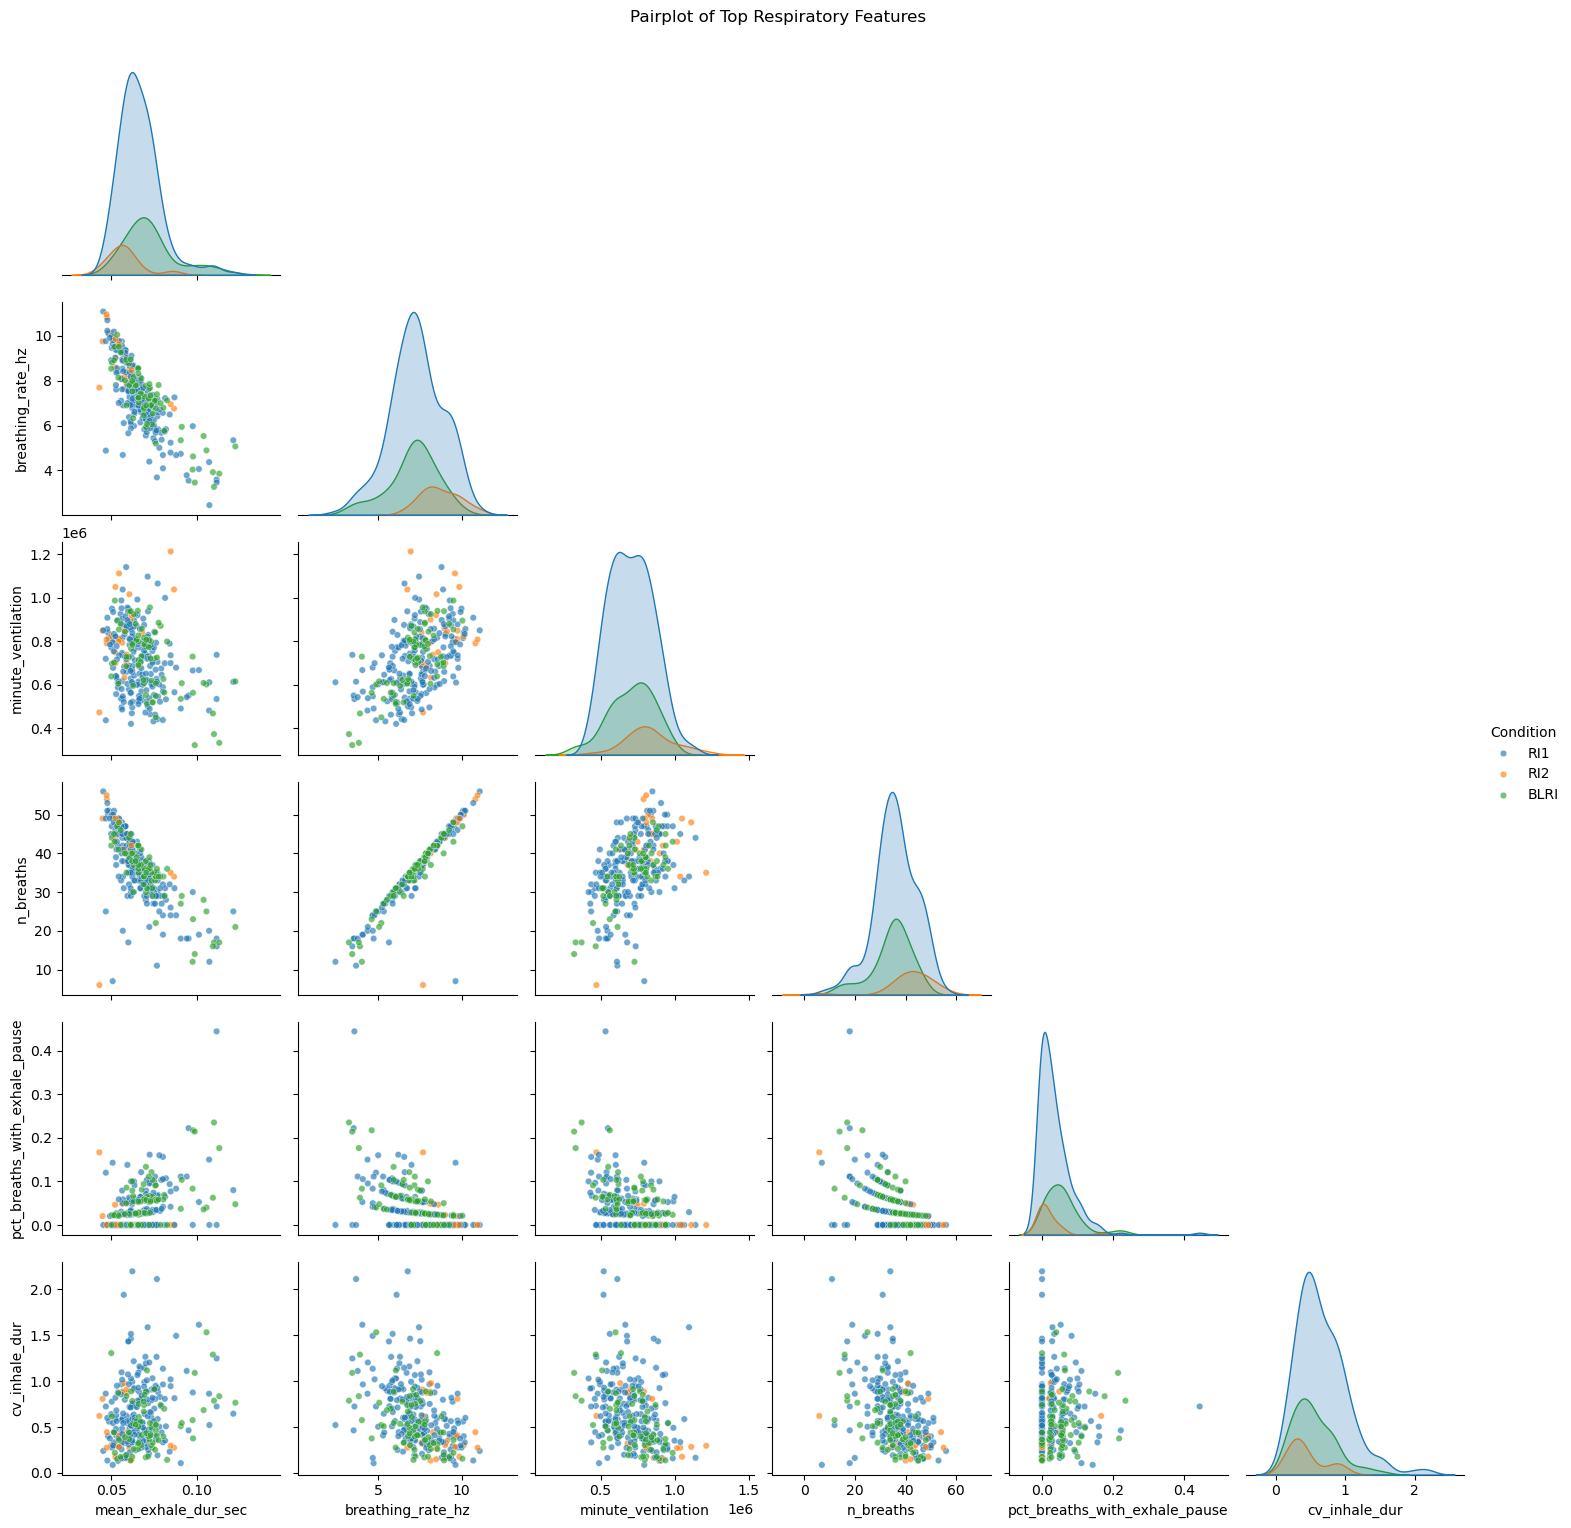

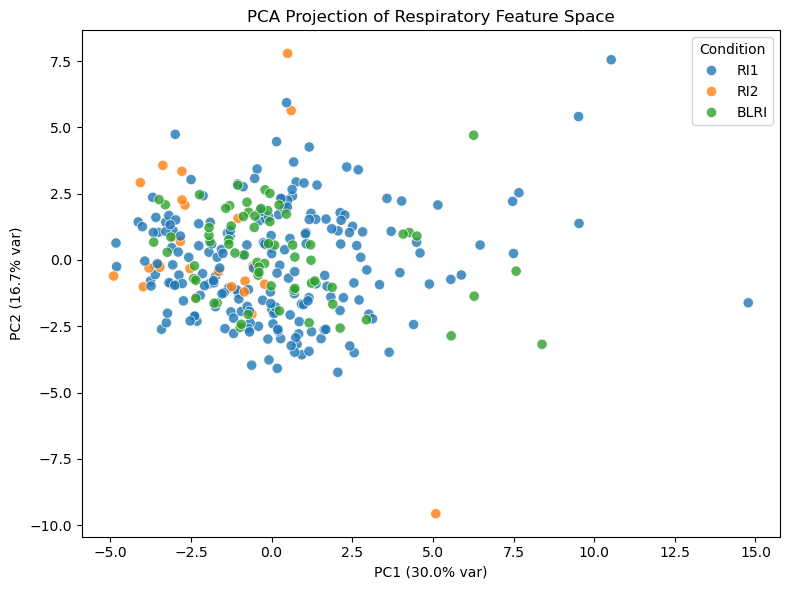

Total variance explained by PC1+PC2: 46.72%


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_classif

# Use the preprocessed feature matrix from earlier cells
# and fill missing values for visualization-only steps.
imputer = SimpleImputer(strategy="median")
X_vis = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

# Select top features by ANOVA F-score for compact pairplot visualization
N_TOP_FEATURES = 6
f_scores, _ = f_classif(X_vis, y)
feature_rank = pd.Series(f_scores, index=X_vis.columns).sort_values(ascending=False)
top_features = feature_rank.head(N_TOP_FEATURES).index.tolist()

print("Top features used in pairplot:", top_features)
display(feature_rank.head(12).to_frame(name="anova_f_score"))

pairplot_df = X_vis[top_features].copy()
pairplot_df[TARGET_COL] = y.values

sns.pairplot(
    pairplot_df,
    hue=TARGET_COL,
    corner=True,
    diag_kind="kde",
    plot_kws={"alpha": 0.65, "s": 22},
)
plt.suptitle("Pairplot of Top Respiratory Features", y=1.02)
plt.show()

# PCA on all retained respiratory features after imputation + scaling
X_vis_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_vis),
    columns=X_vis.columns,
    index=X_vis.index,
)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_vis_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X_vis.index)
pca_df[TARGET_COL] = y.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=TARGET_COL,
    alpha=0.8,
    s=55,
)
plt.title("PCA Projection of Respiratory Feature Space")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
plt.legend(title=TARGET_COL)
plt.tight_layout()
plt.show()

print(
    f"Total variance explained by PC1+PC2: "
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

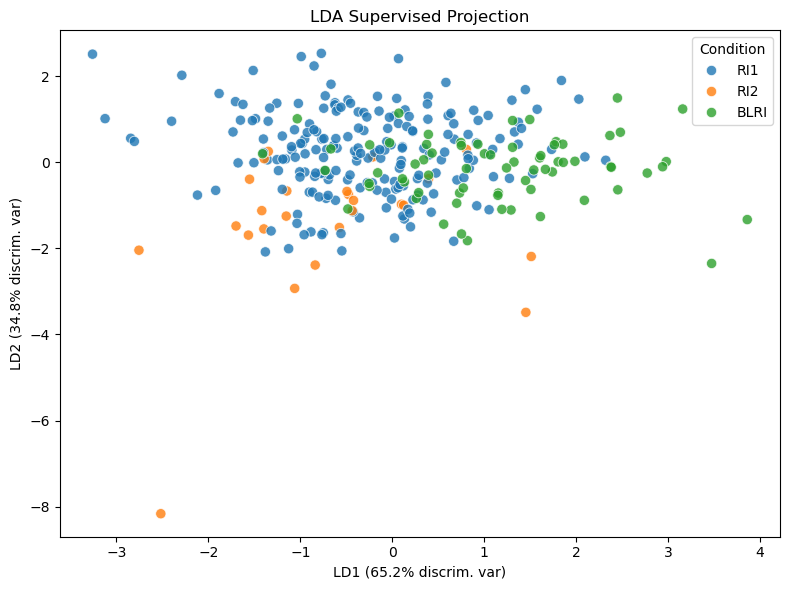

Top features by ANOVA separability:


,feature,F_score,p_value
0,mean_exhale_dur_sec,13.067159,0.000004
1,breathing_rate_hz,11.560828,0.000015
2,minute_ventilation,8.005142,0.000410
3,n_breaths,7.997783,0.000413
4,pct_breaths_with_exhale_pause,7.438617,0.000703
5,cv_inhale_dur,6.956588,0.001114
6,mean_ibi_sec,6.917524,0.001157
7,exhale_duty_cycle,6.788220,0.001309
8,cv_breathing_rate,6.587794,0.001586
9,cv_exhale_dur,6.171104,0.002365


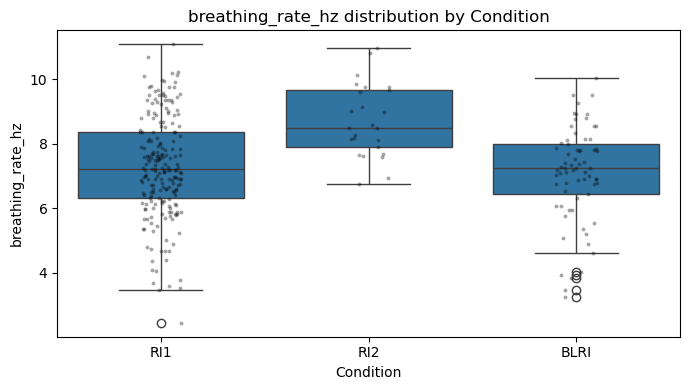

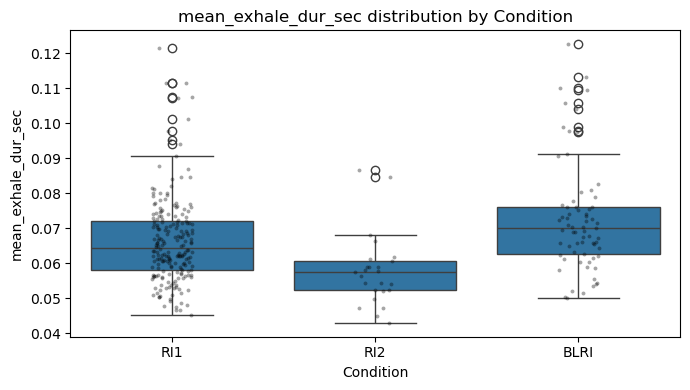

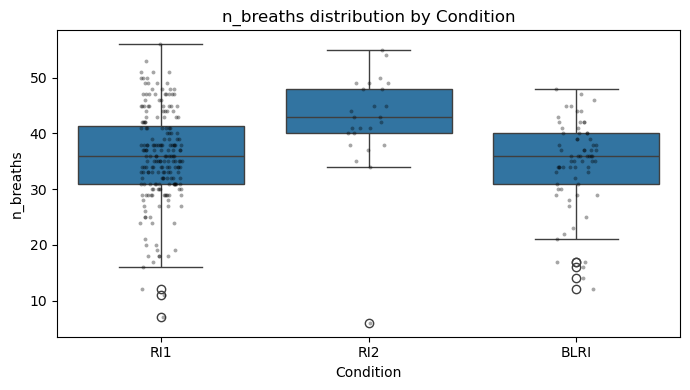

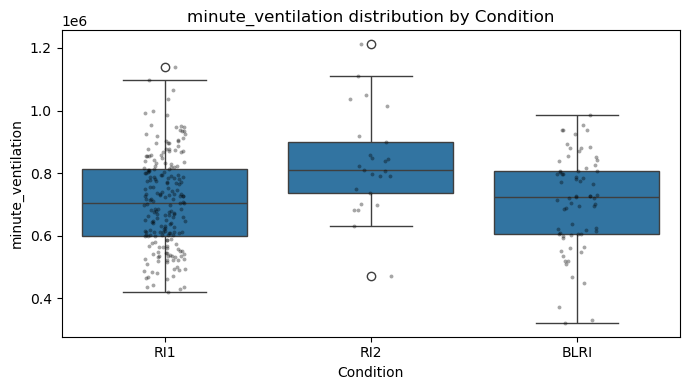

Mean -log10(p) of top 10 features: 3.44


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import f_classif
from sklearn.impute import SimpleImputer

# Impute + scale for supervised projection inputs
X_lda_input = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X),
    columns=X.columns,
    index=X.index,
)
X_lda_input = pd.DataFrame(
    StandardScaler().fit_transform(X_lda_input),
    columns=X_lda_input.columns,
    index=X_lda_input.index,
)

# LDA supervised projection (max 2 components for 3 classes)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_lda_input, y)

lda_cols = [f"LD{i + 1}" for i in range(X_lda.shape[1])]
lda_df = pd.DataFrame(X_lda, columns=lda_cols, index=X.index)
lda_df[TARGET_COL] = y.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=lda_df,
    x="LD1",
    y="LD2" if "LD2" in lda_df.columns else "LD1",
    hue=TARGET_COL,
    s=55,
    alpha=0.8,
)
plt.title("LDA Supervised Projection")
if hasattr(lda, "explained_variance_ratio_"):
    ratios = lda.explained_variance_ratio_
    if len(ratios) >= 2:
        plt.xlabel(f"LD1 ({ratios[0] * 100:.1f}% discrim. var)")
        plt.ylabel(f"LD2 ({ratios[1] * 100:.1f}% discrim. var)")
    elif len(ratios) == 1:
        plt.xlabel(f"LD1 ({ratios[0] * 100:.1f}% discrim. var)")
        plt.ylabel("LD1")
plt.tight_layout()
plt.show()

# ANOVA-based separability quantification
F, p = f_classif(X_lda_input, y)
sep_table = (
    pd.DataFrame({"feature": X_lda_input.columns, "F_score": F, "p_value": p})
    .sort_values("F_score", ascending=False)
    .reset_index(drop=True)
)

print("Top features by ANOVA separability:")
display(sep_table.head(15))

# Feature distribution plots per class
candidate_plot_features = ["breathing_rate_hz", "mean_exhale_dur_sec", "n_breaths", "minute_ventilation"]
plot_features = [f for f in candidate_plot_features if f in df.columns]
if not plot_features:
    plot_features = sep_table.head(4)["feature"].tolist()

for feat in plot_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x=TARGET_COL, y=feat, order=TARGET_CLASSES)
    sns.stripplot(data=df, x=TARGET_COL, y=feat, order=TARGET_CLASSES, alpha=0.35, color="black", size=2.8)
    plt.title(f"{feat} distribution by {TARGET_COL}")
    plt.tight_layout()
    plt.show()

# A compact separability summary metric
mean_neg_log10_p_top10 = float((-np.log10(sep_table["p_value"].clip(lower=1e-300))).head(10).mean())
print(f"Mean -log10(p) of top 10 features: {mean_neg_log10_p_top10:.2f}")